# Megaline Plan Revenue Analysis

## Business Problem

As a data analyst for Megaline, I evaluated two prepaid plans—Surf and Ultimate—to determine which generates higher revenue. The goal is to inform marketing spend allocation based on plan performance.

Using a sample of 500 customers, I analyzed usage behavior (calls, messages, and data) and applied statistical methods to compare revenue across plans. The analysis focuses on identifying meaningful differences in customer behavior and determining whether those differences translate into higher profitability.

## Context
This project uses a simulated telecom dataset and approaches the problem as a business-focused revenue analysis. The goal is to compare customer behavior across plans, evaluate revenue performance, and provide recommendations supported by statistical evidence.

## Initialization

The analysis begins by importing the core libraries used for data manipulation, visualization, and statistical testing.

In [ ]:
from scipy import stats as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load data

Loaded the source tables for calls, messages, internet usage, plans, and users.

In [ ]:
megaline_calls = pd.read_csv('/datasets/megaline_calls.csv')
megaline_internet = pd.read_csv('/datasets/megaline_internet.csv')
megaline_messages = pd.read_csv('/datasets/megaline_messages.csv') 
megaline_plans = pd.read_csv('/datasets/megaline_plans.csv')
megaline_users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare the data

Reviewed each table to assess structure, data types, missing values, and potential preprocessing needs before analysis.

### Checking Info for all Tables

**Calls Table Info:**

In [ ]:
print(megaline_calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


**Calls Table 'id' Column Sample:**

In [ ]:
print(megaline_calls['id'].sample(5, random_state = 42))

52288     1187_481
30634     1114_568
54228     1196_106
110372    1389_454
109600     1386_60
Name: id, dtype: object


**Assessment**
- `call_date` is stored as an object and should be converted to a datetime type for time-based analysis.
- No immediate structural issues are visible beyond the date formatting.

**Internet Table Info**

In [ ]:
print(megaline_internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


**Assessment**
- The 'session_date' is showing as an object, likely a string. Thus, it needs to be converted to a date and time type.
- The id is an object, but this is expected, given it represents both the ID for the user and the ID for the internet session, with underscores separating each.
- The fact that the 'mb_used' values are floats is expected, since they represent megabites. However, it's important to note that I'll need to divide these each by 1,024 and round them up to the nearest integer when calculating costs. This is because megabytes are rounded up to the nearest 1.024 gigabytes when calculating for billing.

**Messages Table Info**

In [ ]:
print(megaline_messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


**Assessment**
- The 'message_date' is showing as an object, likely a string. Thus, it needs to be converted to a date and time type.
- The id is an object, but this is expected, given it represents both the ID for the user and the ID for the message, with underscores separating each.

**Plans Table Info**

In [ ]:
print(megaline_plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


**Assessment**
- The plans table is small, structurally clean, and does not require major preprocessing.
- It will serve as the pricing reference for monthly revenue calculations.

**Users Table Info**

In [ ]:
print(megaline_users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


**Assessment**
- The users table appears structurally sound.
- Integer data types for `user_id` and `age` are appropriate.
- Date fields will need to be standardized before downstream analysis.

## Plans

In [ ]:
print(megaline_plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [ ]:
print(megaline_plans.sample())

   messages_included  mb_per_month_included  minutes_included  \
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
1               70           7             0.01            0.01  ultimate  


**Assessment**
- While all of these data types are to be expected, there are some important things to keep in mind.
- The floats represent costs per message and minute in US dollars.
- The integers represent how many messages, megabytes, and minutes are included in each plan. These are the exact points at which we start counting messages, megabytes, and minutes to determine if extra charges will be billed beyond the monthly plan's cost.
- The remaining integers are for even US dollar amounts. These accounting for each plan's cost per month and cost per gigabyte.
- There is no missing data.

### Fix data

- There are no dates to correct from objects to date and time types.
- Checked the plans table for duplicate rows

In [ ]:
print(f'Plans Table Duplicates: {megaline_plans.duplicated().sum()}')

Plans Table Duplicates: 0


- Checked the plans table for missing values

In [ ]:
megaline_plans.isna().sum()

messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

- No additional cleaning is required for the plans table. It contains the pricing and usage limits needed for revenue modeling.

### Enrich data

- Checked for obvious opportunities to enrich the data at this stage. While I will enrich parts of it later, there's nothing to enrich at this point.

## Users

In [ ]:
# Printed the general/summary information about the users' DataFrame

print(megaline_users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [ ]:
# Printed a sample of data for users

print(megaline_users.sample(5, random_state = 42))

     user_id first_name last_name  age  \
361     1361    Jacelyn   Hoffman   45   
73      1073      Grady  Crawford   30   
374     1374      Ching     Watts   55   
155     1155     Claude      Hahn   19   
104     1104    Thurman  Stephens   20   

                                              city    reg_date      plan  \
361                      Birmingham-Hoover, AL MSA  2018-04-14      surf   
73          Chicago-Naperville-Elgin, IL-IN-WI MSA  2018-04-06      surf   
374         Louisville/Jefferson County, KY-IN MSA  2018-02-14      surf   
155  Miami-Fort Lauderdale-West Palm Beach, FL MSA  2018-02-21  ultimate   
104         Chicago-Naperville-Elgin, IL-IN-WI MSA  2018-12-23  ultimate   

    churn_date  
361        NaN  
73         NaN  
374        NaN  
155        NaN  
104        NaN  


- The users table is largely complete and suitable for analysis after date conversion.
- The NaT simply indicates that no time or date is available in those rows, which is to be expected for the users who haven't cancelled their plans as of the collection and acquisition of this data.

### Fix Data

- Examined a sample of the 'reg_date' column

In [ ]:
print(megaline_users['reg_date'].sample(1, random_state = 42))

361    2018-04-14
Name: reg_date, dtype: object


- Converted the object values to a date and time type
- Checked to verify the conversion worked with a sample

In [ ]:
megaline_users['reg_date'] = pd.to_datetime(megaline_users['reg_date'], format='%Y-%m-%d')
print(megaline_users['reg_date'].sample(1, random_state = 42))

361   2018-04-14
Name: reg_date, dtype: datetime64[ns]


- Examined a sample of the 'churn_date' column

In [ ]:
print(megaline_users['churn_date'].sample(1, random_state = 42))

361    NaN
Name: churn_date, dtype: object


- Converted the object values to a date and time type
- Checked to verify the conversion worked with a sample

In [ ]:
megaline_users['churn_date'] = pd.to_datetime(megaline_users['churn_date'], format='%Y-%m-%d')
print(megaline_users['churn_date'].sample(1, random_state = 42))

361   NaT
Name: churn_date, dtype: datetime64[ns]


- Checked the users table for duplicate rows

In [ ]:
print(f'Users Table Duplicates: {megaline_users.duplicated().sum()}')

Users Table Duplicates: 0


- Checked the users table for missing values

In [ ]:
megaline_users.isna().sum()

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

- Missing values in `churn_date` are expected and indicate customers who had not canceled their plans at the time of data collection.

### Enrich Data

- Checked for obvious opportunities to enrich the data at this stage. While I will enrich parts of it later, there's nothing to enrich at this point.

## Calls

In [ ]:
# Printed the general/summary information about the calls' DataFrame

print(megaline_calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [ ]:
# Printed a sample of data for calls

print(megaline_calls.sample(5, random_state = 42))

              id  user_id   call_date  duration
52288   1187_481     1187  2018-12-12      0.00
30634   1114_568     1114  2018-10-21      1.05
54228   1196_106     1196  2018-07-23      5.67
110372  1389_454     1389  2018-05-12     11.49
109600   1386_60     1386  2018-11-24      0.00


- The primary preprocessing issue in the calls table was the date field, which was standardized to support accurate monthly analysis.

### Fix data

**Date Fixes:**
- Examined a sample of the 'call_date' column

In [ ]:
print(megaline_calls['call_date'].sample(5, random_state = 42))

52288     2018-12-12
30634     2018-10-21
54228     2018-07-23
110372    2018-05-12
109600    2018-11-24
Name: call_date, dtype: object


- Converted the object values to a date and time type
- Checked to verify the conversion worked with a sample

In [ ]:
megaline_calls['call_date'] = pd.to_datetime(megaline_calls['call_date'], format='%Y-%m-%d')
print(megaline_calls['call_date'].sample(5, random_state = 42))

52288    2018-12-12
30634    2018-10-21
54228    2018-07-23
110372   2018-05-12
109600   2018-11-24
Name: call_date, dtype: datetime64[ns]


**Duplicates:**
- Checked call DataFrame for duplicate rows

In [ ]:
print(f'Call Table Duplicates: {megaline_calls.duplicated().sum()}')

Call Table Duplicates: 0


- Checked the tables for missing values

In [ ]:
megaline_calls.isna().sum()

id           0
user_id      0
call_date    0
duration     0
dtype: int64

### Enrich data

- Added a month and year column to make calculations easier to approach later on

In [ ]:
megaline_calls['month'] = megaline_calls['call_date'].dt.month
megaline_calls['year'] = megaline_calls['call_date'].dt.year
megaline_calls['duration_rounded'] = np.ceil(megaline_calls['duration'])

- Confirmed the change

In [ ]:
print(megaline_calls.sample(5, random_state = 152))

              id  user_id  call_date  duration  month  year  duration_rounded
125971   1446_60     1446 2018-10-01      2.64     10  2018               3.0
114678  1401_514     1401 2018-09-27      1.70      9  2018               2.0
112240  1394_165     1394 2018-10-20      0.00     10  2018               0.0
18786    1072_72     1072 2018-12-20      4.94     12  2018               5.0
99780   1358_119     1358 2018-07-02      7.05      7  2018               8.0


- Confirmed that the years are all 2018 and dropped the year column as a result.

In [ ]:
print(megaline_calls['year'].unique())
megaline_calls = megaline_calls.drop(columns=['year'])

[2018]


- Added a plan column for future use and confirmed that it worked

In [ ]:
megaline_calls = megaline_calls.merge(megaline_users[['user_id', 'plan']], on='user_id', how='left')
print(megaline_calls.sample(3))

              id  user_id  call_date  duration  month  duration_rounded  \
91787  1329_1140     1329 2018-09-11     21.14      9              22.0   
12649    1055_56     1055 2018-10-10      3.92     10               4.0   
12461   1054_185     1054 2018-07-03      8.87      7               9.0   

           plan  
91787  ultimate  
12649      surf  
12461      surf  


## Messages

In [ ]:
# Printed the general/summary information about the messages' DataFrame

print(megaline_messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [ ]:
# Printed a sample of data for messages

print(megaline_messages.sample(5, random_state = 42))

              id  user_id message_date
58331   1369_132     1369   2018-12-27
24196    1145_51     1145   2018-07-11
9284     1069_42     1069   2018-12-03
44214  1293_1181     1293   2018-10-06
57006    1362_72     1362   2018-05-25


- The issues that are currently a priority have been addressed.
- The 'message_date' is now a datetime data type.
- The 'id' being an object isn't problematic due to it's format (the user ID and message ID, separated by an underscore symbol)

### Fix data

- Examined a sample of the 'message_date' column

In [ ]:
print(megaline_messages['message_date'].sample(1, random_state = 42))

58331    2018-12-27
Name: message_date, dtype: object


- Converted the object values to a date and time type
- Checked to make sure the conversion worked with a sample

In [ ]:
megaline_messages['message_date'] = pd.to_datetime(megaline_messages['message_date'], format='%Y-%m-%d')
print(megaline_messages['message_date'].sample(1, random_state = 42))

58331   2018-12-27
Name: message_date, dtype: datetime64[ns]


- Checked the messages tables for duplicate rows

In [ ]:
print(f'Messages Table Duplicates: {megaline_messages.duplicated().sum()}')

Messages Table Duplicates: 0


- Checked the messages table for missing values, confirming that none are missing

In [ ]:
megaline_messages.isna().sum()

id              0
user_id         0
message_date    0
dtype: int64

### Enrich data

- Extracted the month from the megaline_messages 'call_date' column to create a new 'month' column to simplify future calculations and analysis

In [ ]:
megaline_messages['month'] = megaline_messages['message_date'].dt.month
print(megaline_messages.sample(5, random_state = 32))

             id  user_id message_date  month
6231   1055_349     1055   2018-12-18     12
16686  1111_187     1111   2018-10-28     10
15752  1103_116     1103   2018-09-23      9
53916    1342_3     1342   2018-12-17     12
17370  1114_243     1114   2018-11-04     11


## Internet

In [ ]:
# Print the general/summary information about the internet DataFrame

print(megaline_internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [ ]:
# Print a sample of data for the internet traffic

print(megaline_internet.sample(5, random_state = 42))

              id  user_id session_date  mb_used
102423  1490_238     1490   2018-10-15   373.01
12472   1060_181     1060   2018-09-14   875.38
91959    1426_53     1426   2018-12-29   627.48
42208   1187_385     1187   2018-09-20   132.80
64201   1294_122     1294   2018-10-29   397.70


- The issues that are currently a priority have been addressed.
- The 'session_date' is now a datetime data type.
- The 'id' being an object isn't problematic due to it's format (the user ID and session ID, separated by an underscore symbol)

### Fix data

- Examined a sample of the 'session_date' column

In [ ]:
print(megaline_internet['session_date'].sample(1, random_state = 42))

102423    2018-10-15
Name: session_date, dtype: object


- Converted the object values to a date and time type
- Checked to make sure the conversion worked with a sample

In [ ]:
megaline_internet['session_date'] = pd.to_datetime(megaline_internet['session_date'], format='%Y-%m-%d')
print(megaline_internet['session_date'].sample(1, random_state = 42))

102423   2018-10-15
Name: session_date, dtype: datetime64[ns]


- Checked internet DataFrame for duplicate rows

In [ ]:
print(f'Internet Table Duplicates: {megaline_internet.duplicated().sum()}')

Internet Table Duplicates: 0


- Checked the tables for missing values

In [ ]:
megaline_internet.isna().sum()

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

### Enrich data

- Extracted the month from the megaline_internet 'session_date' column to create a new 'month' column to simplify future calculations and analysis

In [ ]:
megaline_internet['month'] = megaline_internet['session_date'].dt.month
print(megaline_internet.sample(5, random_state = 32))

             id  user_id session_date  mb_used  month
44412  1196_423     1196   2018-07-29   151.27      7
30282  1138_519     1138   2018-04-02   353.31      4
33757  1153_303     1153   2018-11-12     5.71     11
329    1002_345     1002   2018-11-05   357.76     11
10004  1050_427     1050   2018-11-26    70.49     11


## Study plan conditions

Started by reviewing plan conditions to see how users are charged based on their subscription.

In [ ]:
print(megaline_plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Aggregate data per user

- Aggregated data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.

In [ ]:
# Calculate the number of calls made by each user per month. Save the result.

calls_per_month = (megaline_calls.groupby(['user_id', 'month'])['id'].count().reset_index(name='calls_per_month'))
print(calls_per_month.sample(5, random_state = 30))

      user_id  month  calls_per_month
729      1156      9               65
1441     1321      8               62
1715     1377      7               30
1235     1264     10               47
1364     1300     12               75


In [ ]:
# Calculate the amount of minutes spent by each user per month. Save the result.

minutes_per_month = (megaline_calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index(name='minutes_per_month'))

print(minutes_per_month.sample(5, random_state = 30))

      user_id  month  minutes_per_month
729      1156      9              335.0
1441     1321      8              473.0
1715     1377      7              156.0
1235     1264     10              323.0
1364     1300     12              436.0


In [ ]:
# Calculate the number of messages sent by each user per month. Save the result.

messages_per_month = (megaline_messages.groupby(['user_id', 'month'])['id'].count().reset_index(name='messages_per_month'))
print(messages_per_month.sample(5, random_state = 30))

      user_id  month  messages_per_month
789      1211      9                  50
948      1252     11                  30
322      1091     10                  35
1640     1448     10                  19
1391     1373     10                  75


In [ ]:
# Calculate the volume of internet traffic used by each user per month. Save the result.

internet_per_month = (megaline_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index(name='mb_used_per_month'))
print(internet_per_month.sample(5, random_state = 30))

      user_id  month  mb_used_per_month
360      1077      1           10635.64
1923     1411     10           10207.16
1882     1404     10           23884.22
950      1197     11           11032.60
940      1196      3           30960.95


In [ ]:
# Merged the data for calls, minutes, messages, internet based on user_id and month

monthly_usage = calls_per_month.merge(minutes_per_month, on=['user_id', 'month'], how='outer')

monthly_usage = monthly_usage.merge(messages_per_month, on=['user_id', 'month'], how='outer')

monthly_usage = monthly_usage.merge(internet_per_month, on=['user_id', 'month'], how='outer')

In [ ]:
# Added the plan information

monthly_usage = monthly_usage.merge(megaline_users[['user_id', 'plan']], on='user_id', how='left')

monthly_usage = monthly_usage.merge(megaline_plans, left_on='plan', right_on='plan_name', how='left')

# Removed redundant 'plan_name' column

monthly_usage = monthly_usage.drop(columns=['plan_name'])

# Replaced missing usage values with 0 for a cleaner dataframe

monthly_usage[['minutes_per_month', 'messages_per_month', 'calls_per_month', 'mb_used_per_month']] = (
    monthly_usage[['minutes_per_month', 'messages_per_month', 'calls_per_month', 'mb_used_per_month']].fillna(0))

print(monthly_usage.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   int64  
 1   month                  2293 non-null   int64  
 2   calls_per_month        2293 non-null   float64
 3   minutes_per_month      2293 non-null   float64
 4   messages_per_month     2293 non-null   float64
 5   mb_used_per_month      2293 non-null   float64
 6   plan                   2293 non-null   object 
 7   messages_included      2293 non-null   int64  
 8   mb_per_month_included  2293 non-null   int64  
 9   minutes_included       2293 non-null   int64  
 10  usd_monthly_pay        2293 non-null   int64  
 11  usd_per_gb             2293 non-null   int64  
 12  usd_per_message        2293 non-null   float64
 13  usd_per_minute         2293 non-null   float64
dtypes: float64(6), int64(7), object(1)
memory usage: 268.7+ 

**Calculated the monthly revenue for each user:**
- Added up any additional minutes, messages, and megabytes that were used beyond what the plan includes
- Multiplied each by the rate in USD for each
- Added those to the monthly plan cost

In [ ]:
# Calculate the monthly revenue for each user

monthly_revenue = []

for i in range(len(monthly_usage)):
    revenue = monthly_usage['usd_monthly_pay'][i]

    if monthly_usage['minutes_per_month'][i] > monthly_usage['minutes_included'][i]:
        revenue += (monthly_usage['minutes_per_month'][i] - monthly_usage['minutes_included'][i]) * monthly_usage['usd_per_minute'][i]

    if monthly_usage['messages_per_month'][i] > monthly_usage['messages_included'][i]:
        revenue += (monthly_usage['messages_per_month'][i] - monthly_usage['messages_included'][i]) * monthly_usage['usd_per_message'][i]

    if monthly_usage['mb_used_per_month'][i] > monthly_usage['mb_per_month_included'][i]:
        extra_gb = np.ceil((monthly_usage['mb_used_per_month'][i] - monthly_usage['mb_per_month_included'][i]) / 1024)
        revenue += extra_gb * monthly_usage['usd_per_gb'][i]

    monthly_revenue.append(np.round(revenue, 2))

monthly_usage['monthly_revenue'] = monthly_revenue

In [ ]:
# Checked to make sure the calculations are working correctly

print(monthly_usage.sample(5, random_state = 583375))

      user_id  month  calls_per_month  minutes_per_month  messages_per_month  \
1134     1247     11             79.0              587.0               121.0   
1518     1335     12             63.0              441.0                89.0   
84       1023      8             11.0               72.0                 6.0   
1757     1385     12             76.0              563.0                43.0   
2083     1460      6             57.0              366.0                59.0   

      mb_used_per_month      plan  messages_included  mb_per_month_included  \
1134           17459.46  ultimate               1000                  30720   
1518           16815.88      surf                 50                  15360   
84              9991.79      surf                 50                  15360   
1757           16602.79      surf                 50                  15360   
2083           33687.73  ultimate               1000                  30720   

      minutes_included  usd_monthly_pay  usd

**Additional Task:**
- Adding NY-NJ area indicator to 'monthly_usage' DataFrame for future use. Later in this project, I'll compare users who live in NY-NJ with those who don't.

In [ ]:
# Created NY-NJ indicator in the users DataFrame

megaline_users['is_ny_nj'] = megaline_users['city'].str.contains('New York-Newark-Jersey City, NY-NJ-PA MSA', na=False)

# Merged the geographic indicator into the monthly_usage DataFrame

monthly_usage = monthly_usage.merge(megaline_users[['user_id', 'is_ny_nj']], on='user_id', how='left')

## Study user behaviour

- Separated user behavior into the two plan categories for further study

In [ ]:
# Separated the user behavior data by plan

surf_users = monthly_usage[monthly_usage['plan'] == 'surf']
ultimate_users = monthly_usage[monthly_usage['plan'] == 'ultimate']

- Calculated some useful descriptive statistics for the aggregated and merged data, revealing an overall picture captured by the data.

In [ ]:
# Calculated Surf and Unlimited average minutes for a cursory glance at the data

surf_minutes_mean = surf_users['minutes_per_month'].mean()
surf_minutes_std = surf_users['minutes_per_month'].std()
ult_minutes_mean = ultimate_users['minutes_per_month'].mean()
ult_minutes_std = ultimate_users['minutes_per_month'].std()

print(f"Surf plan - Average Minutes per Month: {surf_minutes_mean:.2f}")
print(f"Surf plan - Minutes per Month Standard Deviation: {surf_minutes_std:.2f}")
print(f"Ultimate plan - Average Minutes per Month: {ult_minutes_mean:.2f}")
print(f"Ultimate plan - Minutes per Month Standard Deviation: {ult_minutes_std:.2f}")

Surf plan - Average Minutes per Month: 428.75
Surf plan - Minutes per Month Standard Deviation: 234.45
Ultimate plan - Average Minutes per Month: 430.45
Ultimate plan - Minutes per Month Standard Deviation: 240.51


### Calls

- Compared average total for call durations per each plan per each distinct month, and plotted a bar plot to visualize it

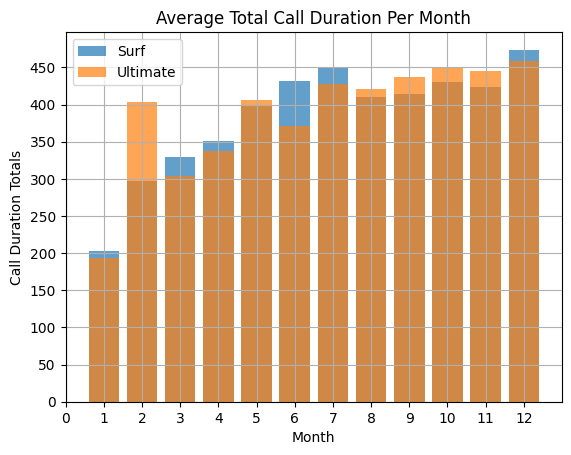

In [ ]:
# Grouped minutes by plan and month, calculating the mean for each

surf_monthly_averages = surf_users.groupby(['plan', 'month'])['minutes_per_month'].mean()
ult_monthly_averages = ultimate_users.groupby(['plan', 'month'])['minutes_per_month'].mean()

# Extracted the values from the newly created GroupBy objects for plotting
surf_values = surf_monthly_averages.values
ult_values = ult_monthly_averages.values
months = range(1, 13)  # months 1-12

# Create the bar plot

plt.bar(months, surf_values,alpha=0.7,  label='Surf')
plt.bar(months, ult_values, alpha=0.7, label='Ultimate')
plt.xlabel('Month')
plt.ylabel('Call Duration Totals')
plt.title('Average Total Call Duration Per Month')
plt.legend()
plt.xticks(range(0, 13, 1))
plt.yticks(range(0, 500, 50))
plt.grid(True)

plt.show()

**Analysis:**
- For both plans, the average totals for call durations peaks in December.
- The lowest average total is in January.
- The average quickly spikes for Ultimate users in Februrary.
- Overall, there's a general increase in usage for both plans.
- Ultimate durations drop quite a bit in June, whereas Surf durations remain steady.

**Next Task:**
- Plotted a histogram to compared the distributions of users by plan and the minutes used per month.

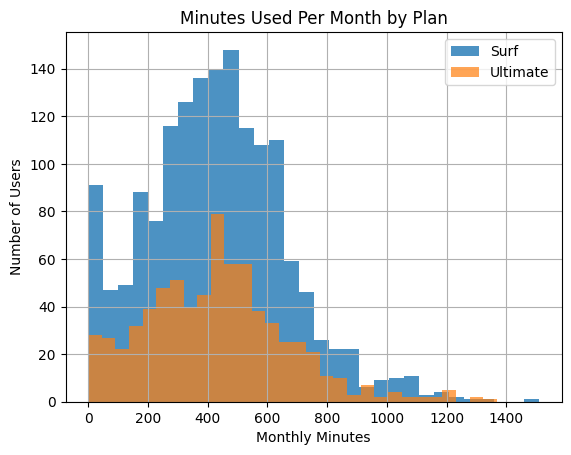

In [ ]:
# Plotted histogram for Surf and Ultimate users
plt.hist(surf_users['minutes_per_month'], bins=30, alpha=0.8, label='Surf')
plt.hist(ultimate_users['minutes_per_month'], bins=30, alpha=0.7, label='Ultimate')

# Added labels and formatting
plt.xlabel('Monthly Minutes')
plt.ylabel('Number of Users')
plt.title('Minutes Used Per Month by Plan')
plt.legend()
plt.xticks(range(0, 1500, 200))
plt.yticks(range(0, 160, 20))
plt.grid(True)

plt.show()

**Analysis:**
- The user distribution for both plans peaks at about 400 minutes per month, which is consistent with the averages we calculated earlier.
- There's a decent spike in the distribution of Surf customer who use zero or close to zero minutes per month.
- The distribution of users who use more than 600 minutes drops off significantly for both plans, especially Surf users.

In [ ]:
# Calculate the mean and the variance of the monthly call duration

surf_minutes_mean = surf_users['minutes_per_month'].mean()
ult_minutes_mean = ultimate_users['minutes_per_month'].mean()
surf_minutes_var = surf_users['minutes_per_month'].var()
ult_minutes_var = ultimate_users['minutes_per_month'].var()

print('Minutes per Month:')
print()
print(f"Surf plan - Average: {surf_minutes_mean:.2f}")
print(f"Ultimate plan - Average: {ult_minutes_mean:.2f}")
print()
print(f"Surf plan - Variance: {surf_minutes_var:.2f}")
print(f"Ultimate plan - Variance: {ult_minutes_var:.2f}")

Minutes per Month:

Surf plan - Average: 428.75
Ultimate plan - Average: 430.45

Surf plan - Variance: 54968.28
Ultimate plan - Variance: 57844.46


**Analysis:**
- The Ultimate plan has a slightly higher average of minutes used per month.
- The Ultimate plan also has a slightly higher variance, meaning call durations vary more.

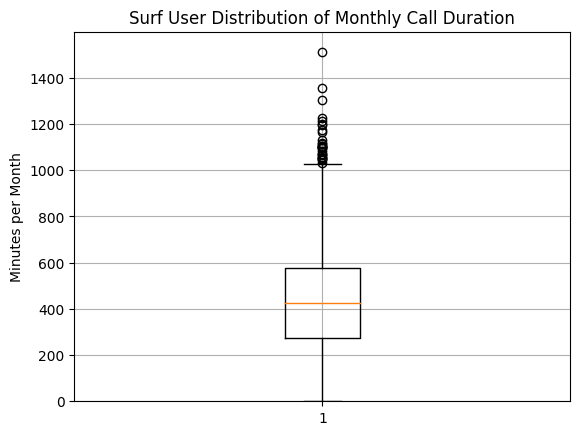

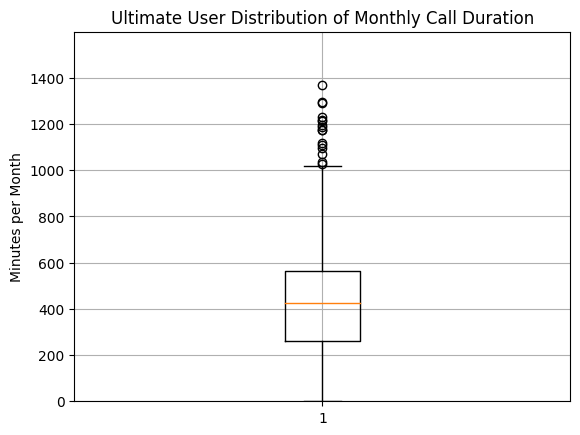

In [ ]:
# Plotted a boxplot to visualize the distribution of the monthly call duration for each type of user

plt.boxplot(surf_users['minutes_per_month'])
plt.ylabel('Minutes per Month') 
plt.title('Surf User Distribution of Monthly Call Duration')
plt.yticks(range(0, 1600, 200))
plt.ylim(0, 1600)
plt.grid(True)
plt.show()

plt.boxplot(ultimate_users['minutes_per_month'])
plt.ylabel('Minutes per Month') 
plt.title('Ultimate User Distribution of Monthly Call Duration')
plt.yticks(range(0, 1600, 200))
plt.ylim(0, 1600)
plt.grid(True)
plt.show()

**Analysis:**
- The Surf users contains a greater number of outliers at a higher number of minutes per month, meaning these are heavy users that could benefit from and be targeted for promotions. Such promotions could encourage them to upgrade and include savings they could have gained previously.
- Overall, both are skewed to the right, keeping that median around 400 minutes.
- Overall, it doesn't seem like a higher allowance of minutes included in each plan has a significant influence on call duration, meaning other factors are probably what influences them to choose that plan.

### Messages

- Compared the number of messages users of each plan tend to send each month

In [ ]:
# Calculated Surf and Unlimited average messages

surf_messages_mean = surf_users['messages_per_month'].mean()
surf_messages_std = surf_users['messages_per_month'].std()
ult_messages_mean = ultimate_users['messages_per_month'].mean()
ult_messages_std = ultimate_users['messages_per_month'].std()

print("Messages Per Month:")
print()
print(f"Surf plan - Average: {surf_messages_mean:.2f}")
print(f"Ultimate plan - Average: {ult_messages_mean:.2f}")
print()
print(f"Ultimate plan - Standard Deviation: {ult_messages_std:.2f}")
print(f"Surf plan - Standard Deviation: {surf_messages_std:.2f}")

Messages Per Month:

Surf plan - Average: 31.16
Ultimate plan - Average: 37.55

Ultimate plan - Standard Deviation: 34.77
Surf plan - Standard Deviation: 33.57


**Analysis:**
- The Ultimate plan has a slightly higher average of messages used per month.
- The Ultimate plan also has a slightly higher standard deviation, meaning the plan attracts users with varying call duration patterns

**Next Step:**
- Compared average total for messages used for each plan in each distinct month, and created a bar plot to visualize it

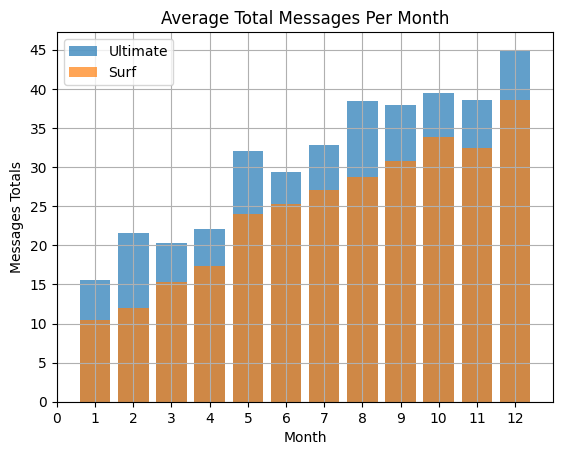

In [ ]:
# Grouped messages by plan and month, calculating the mean for each

surf_monthly_message_averages = surf_users.groupby(['plan', 'month'])['messages_per_month'].mean()
ult_monthly_message_averages = ultimate_users.groupby(['plan', 'month'])['messages_per_month'].mean()

# Extracted the values from the newly created GroupBy objects for plotting

surf_message_values = surf_monthly_message_averages.values
ult_message_values = ult_monthly_message_averages.values
months = range(1, 13)  # months 1-12

# Create the bar plot

plt.bar(months, ult_message_values, alpha=0.7, label='Ultimate')
plt.bar(months, surf_message_values,alpha=0.7,  label='Surf')
plt.xlabel('Month')
plt.ylabel('Messages Totals')
plt.xticks(range(0, 13, 1))
plt.yticks(range(0, 50, 5))
plt.title('Average Total Messages Per Month')
plt.legend()

plt.grid(True)

plt.show()

**Analysis:**
- I find it striking that on average so much of each user's message capacity is not being used.
- Ultimate users get 1,000 text messages included with their plan and Surf users get 50.
- For both plans, the average totals for messages used peaks in December--just as with calls.
- The lowest average total is in January, as is true for calls.
- There's more consistency in the difference between the two plans throughout the year.

**Next Task:**
- Plotted a histogram to compared the distributions of users by plan and the messages used per month.

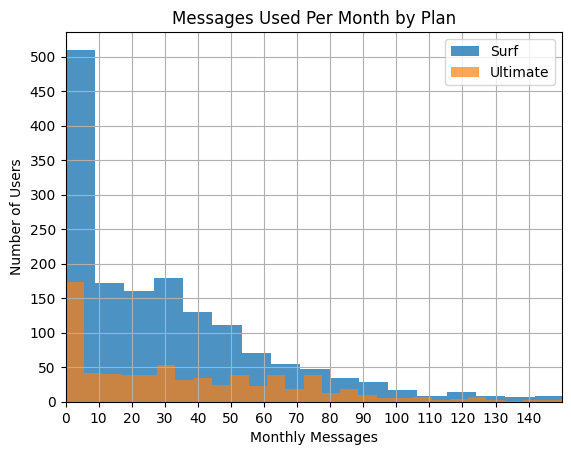

In [ ]:
# Plotted histogram for Surf and Ultimate users
plt.hist(surf_users['messages_per_month'], bins=30, alpha=0.8, label='Surf')
plt.hist(ultimate_users['messages_per_month'], bins=30, alpha=0.7, label='Ultimate')

# Added labels and formatting
plt.xlabel('Monthly Messages')
plt.ylabel('Number of Users')
plt.title('Messages Used Per Month by Plan')
plt.legend()
plt.xlim(0, 150)
plt.yticks(range(0, 550, 50))
plt.xticks(range(0, 150, 10))
plt.grid(True)

plt.show()

**Analysis:**
- The user distribution for both plans drops off significantly after 30 messages per month, which is consistent with the averages we calculated earlier.
- There's a decent spike in the distribution of Surf and Ultimate customer who use 0 to 10 messages per month, meaning many customers don't use all their alloted messages.

**Next Task:**
- Created a boxplot to visualize the distribution of monthly message use for each type of user

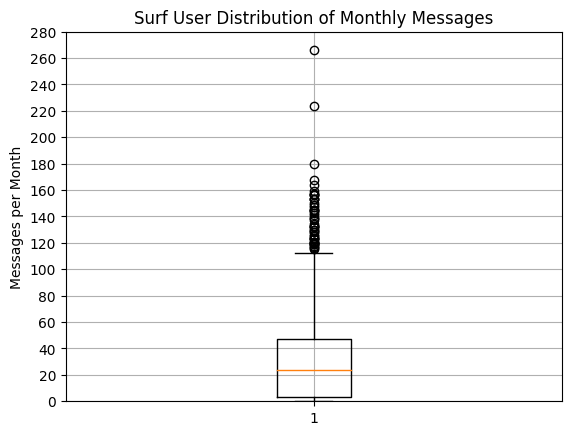

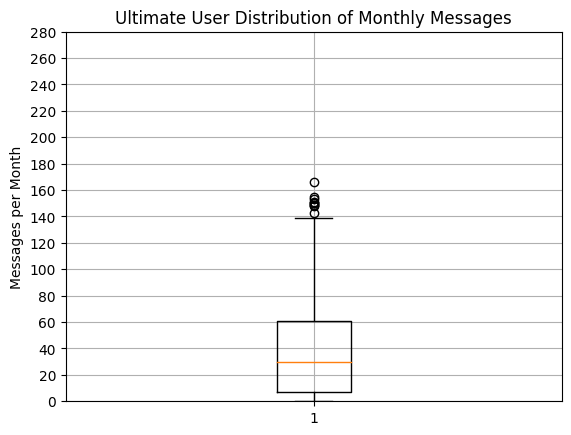

In [ ]:
# Plotted a boxplot to visualize the distribution of the monthly call messages for each type of user

plt.boxplot(surf_users['messages_per_month'])
plt.ylabel('Messages per Month') 
plt.title('Surf User Distribution of Monthly Messages')
plt.grid(True)
plt.yticks(range(0, 300, 20))
plt.ylim(0, 280)
plt.show()

plt.boxplot(ultimate_users['messages_per_month'])
plt.ylabel('Messages per Month') 
plt.title('Ultimate User Distribution of Monthly Messages')
plt.grid(True)
plt.yticks(range(0, 300, 20))
plt.ylim(0, 280)
plt.show()

**Analysis:**
- The median for Ultimate users is just above 30. For Surf users, it's just above 20.
- The Surf users contains a greater number of outliers at a higher number of messages used per month, meaning these are heavy users that could benefit from and be targeted for upselling. Such promotions could encourage them to upgrade and include savings they could have gained previously--considering their overages are well within the Ultimate plan's included messages per month.
- Overall, we are seeing that the number of messages included in each plan is having an impact on behavior. Many on the Surf plan probably want to use more messages (like the outliers did), but the bulk of Surf users manage to keep within the plans included messages.
- Despite all this, Ultimate users don't put much of a strain on network. Their usage is nothing compared to the number of text messages their plans include.

### Internet

- Compared the number of megabytes users of each plan tend to send each month

In [ ]:
# Calculated Surf and Unlimited average megabytes

surf_megabytes_mean = surf_users['mb_used_per_month'].mean()
surf_megabytes_std = surf_users['mb_used_per_month'].std()
ult_megabytes_mean = ultimate_users['mb_used_per_month'].mean()
ult_megabytes_std = ultimate_users['mb_used_per_month'].std()

print("Megabytes Per Month:")
print()
print(f"Surf plan - Average: {surf_megabytes_mean:.0f}")
print(f"Ultimate plan - Average: {ult_megabytes_mean:.0f}")
print()
print(f"Ultimate plan - Standard Deviation: {ult_megabytes_std:.0f}")
print(f"Surf plan - Standard Deviation: {surf_megabytes_std:.0f}")

Megabytes Per Month:

Surf plan - Average: 16558
Ultimate plan - Average: 17215

Ultimate plan - Standard Deviation: 7852
Surf plan - Standard Deviation: 8014


**Next Task:**
- Created a histogram to compare the average total megabytes used per month by plan type

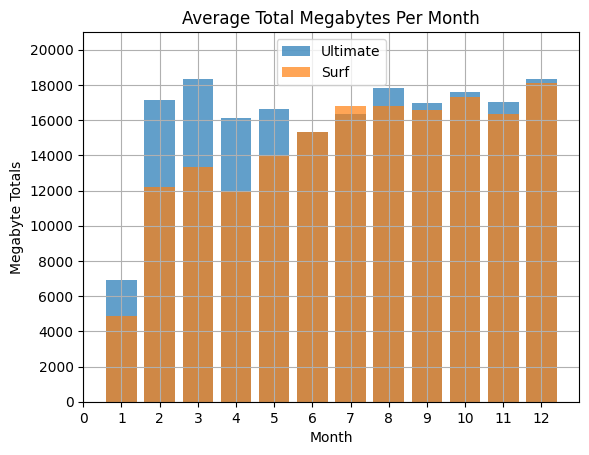

In [ ]:
# Grouped megabytes by plan and month, calculating the mean for each

surf_monthly_message_averages = surf_users.groupby(['plan', 'month'])['mb_used_per_month'].mean()
ult_monthly_message_averages = ultimate_users.groupby(['plan', 'month'])['mb_used_per_month'].mean()

# Extracted the values from the newly created GroupBy objects for plotting

surf_message_values = surf_monthly_message_averages.values
ult_message_values = ult_monthly_message_averages.values
months = range(1, 13)  # months 1-12

# Create the bar plot

plt.bar(months, ult_message_values, alpha=0.7, label='Ultimate')
plt.bar(months, surf_message_values,alpha=0.7,  label='Surf')
plt.xlabel('Month')
plt.ylabel('Megabyte Totals')
plt.xticks(range(0, 13, 1))
plt.yticks(range(0, 21000, 2000))
plt.ylim(0, 21000)
plt.title('Average Total Megabytes Per Month')
plt.legend()

plt.grid(True)

plt.show()


**Analysis:**
- Until the month of June, Surf users stay within their plan's allotment. After that, they exceed their plan's included megabytes each month for the rest of the year. This might be the perfect time to target them for an upgrade to the Ultimate plan. 
- For both plans, the average totals for megabytes used has a peak in December--just as with calls and messages. However, there's another similarly high peak for megabytes used in March for Ultimate users.
- The lowest average total is in January, as is true for calls and messages.
- There's less consistency in the difference between the two plans throughout the year. In the first half of the year, Ultimate customers use significantly more megabytes.
- What's particularly unique about this data is that--other than January--Ultimate customers use their megabytes in a fairly consistent way from month to month. Surf users are much less consistent.
- Ultimate users rarely use their full allotment of megabytes and don't put much of an additional strain on the Megaline network.

 **Next Task:**
- Plotted a histogram to compared the distributions of users by plan and the megabytes used per month.

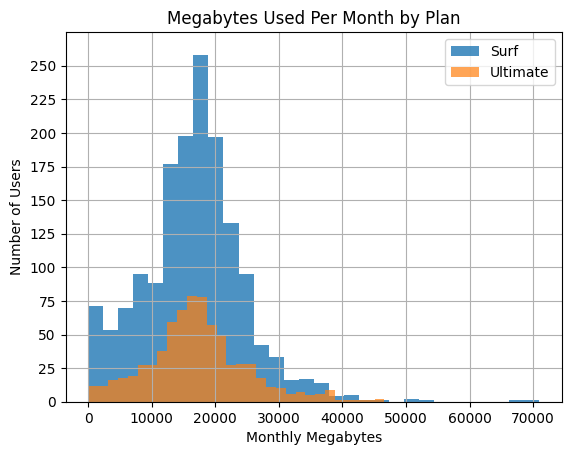

In [ ]:
# Plotted histogram for Surf and Ultimate users
plt.hist(surf_users['mb_used_per_month'], bins=30, alpha=0.8, label='Surf')
plt.hist(ultimate_users['mb_used_per_month'], bins=30, alpha=0.7, label='Ultimate')

# Added labels and formatting
plt.xlabel('Monthly Megabytes')
plt.ylabel('Number of Users')
plt.title('Megabytes Used Per Month by Plan')
plt.legend()
plt.ylim(0, 275)
plt.yticks(range(0, 275, 25))
plt.grid(True)

plt.show()

**Analysis:**
- The peak of the distribution is at the same point for both Surf and Ultimate users.
- The shape of the distribution for both users is also similar, indicating user behavior doesn't vary much, regardless of plan type. Thus, customers who upgrade don't tend to put a strain on the Megaline network just because they have more alloted megabytes.
- The user distribution for both plans drops off significantly after 25 gigabytes per month, which is consistent with the averages and standard deviations we calculated earlier.

**Next Task:**
- Created a boxplot to visualize the distribution of monthly message use for each type of user

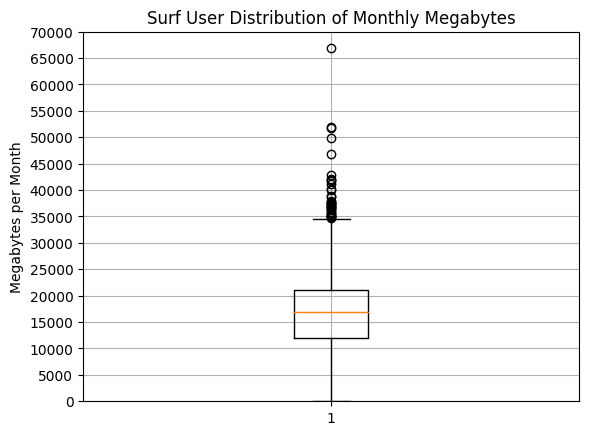

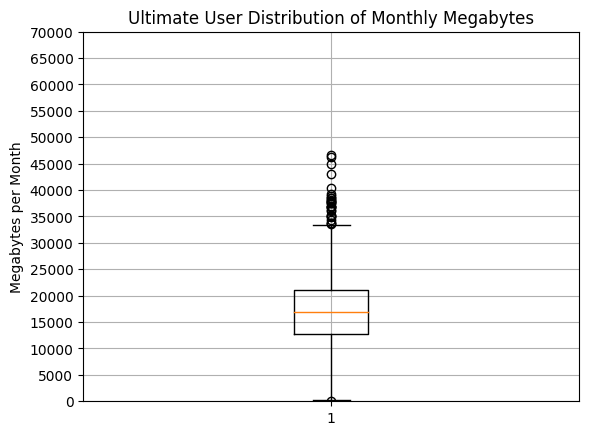

In [ ]:
# Plotted a boxplot to visualize the distribution of the monthly call duration for each type of user

plt.boxplot(surf_users['mb_used_per_month'])
plt.ylabel('Megabytes per Month') 
plt.title('Surf User Distribution of Monthly Megabytes')
plt.grid(True)
plt.yticks(range(0, 75000, 5000))
plt.ylim(0, 70000)
plt.show()

plt.boxplot(ultimate_users['mb_used_per_month'])
plt.ylabel('Megabytes per Month') 
plt.title('Ultimate User Distribution of Monthly Megabytes')
plt.grid(True)
plt.yticks(range(0, 75000, 5000))
plt.ylim(0, 70000)
plt.show()

**Analysis:**
- Here, we can look beyond just the averages. Surf users are much more varied in their data usage than Surf customers. There's a wider spread of outliers among the Surf users and some of those outliers would be perfect targets for upselling to an Ultimate plan.
- The median for both groups of users is between 15 and 20 gigabytes. Since Surf users only get 15 GB with their plans, many of them are exceeding that amount by quite a bit--considering the Surf outliers only start at about 35 GB used.
- It's interesting to see how some of the Surf outliers exceed megabyte usage beyond even the outliers in the Ultimate distribution. Those would be prime candidates for an upgraded plan, seeing as they are exceeding Ultimate customer usage.

## Revenue

- Compared average revenue made per month from users of each plan type

In [ ]:
# Calculated Surf and Unlimited average dollars in revenue

surf_revenue_mean = surf_users['monthly_revenue'].mean()
surf_revenue_std = surf_users['monthly_revenue'].std()
ult_revenue_mean = ultimate_users['monthly_revenue'].mean()
ult_revenue_std = ultimate_users['monthly_revenue'].std()

print("Revenue Made Per Month Per User:")
print()
print(f"Surf plan - Average: ${surf_revenue_mean:.2f}")
print(f"Ultimate plan - Average: ${ult_revenue_mean:.2f}")
print()
print(f"Ultimate plan - Standard Deviation: ${ult_revenue_std:.2f}")
print(f"Surf plan - Standard Deviation: ${surf_revenue_std:.2f}")

Revenue Made Per Month Per User:

Surf plan - Average: $60.71
Ultimate plan - Average: $72.31

Ultimate plan - Standard Deviation: $11.40
Surf plan - Standard Deviation: $55.39


**Nest Task:**
- Plotted a bar chart comparing revenue made in each month of the year by plan type

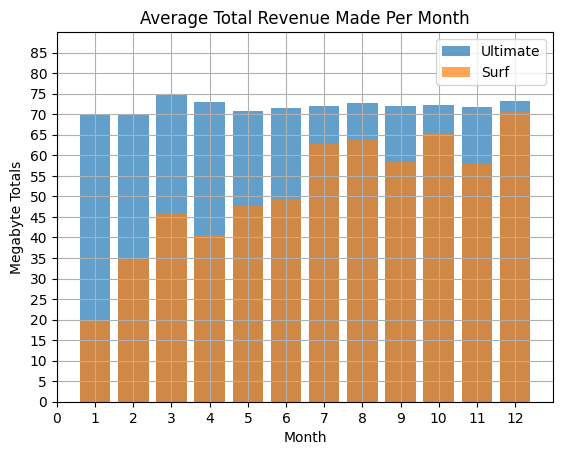

In [ ]:
# Grouped dollars in revenue by plan and month, calculating the mean for each

surf_monthly_message_averages = surf_users.groupby(['plan', 'month'])['monthly_revenue'].mean()
ult_monthly_message_averages = ultimate_users.groupby(['plan', 'month'])['monthly_revenue'].mean()

# Extracted the values from the newly created GroupBy objects for plotting

surf_message_values = surf_monthly_message_averages.values
ult_message_values = ult_monthly_message_averages.values
months = range(1, 13)  # months 1-12

# Create the bar plot

plt.bar(months, ult_message_values, alpha=0.7, label='Ultimate')
plt.bar(months, surf_message_values,alpha=0.7,  label='Surf')
plt.xlabel('Month')
plt.ylabel('Megabyte Totals')
plt.ylim(0, 90)
plt.xticks(range(0, 13, 1))
plt.yticks(range(0, 90, 5))
plt.title('Average Total Revenue Made Per Month')
plt.legend()

plt.grid(True)

plt.show()

**Analysis:**
- The average total revenue made per user is consistently higher for Ultimate customers. Upgrading Surf customers could save a lot of outliers money and it would result in an increase in overall consistent revenue, regardless of the extra fees Surf users pay for exceeding usage.
- Surf users are getting a good deal, but their's an opportunity here for customers to benefit from better plan benefits and Megaline to benefit from more consist revenue.
- The lowest average total for revenue from Surf user plans is in January, making it a key opportunity for upselling and making up a dramatic difference in revenue.
- As the year goes on, that lost revenue is lowered, making it less imperative fo upsell users, considering the gap between the revenue earned between plans start to close more and more--though it never closes completely.

**Next Task:**
- Plotted a histogram to compared the distributions of users by plan and the dollars in revenue earned per month.

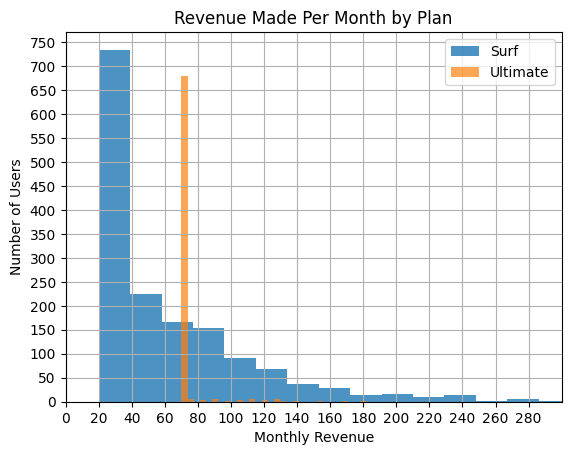

In [ ]:
# Plotted histogram for Surf and Ultimate users
plt.hist(surf_users['monthly_revenue'], bins=30, alpha=0.8, label='Surf')
plt.hist(ultimate_users['monthly_revenue'], bins=30, alpha=0.7, label='Ultimate')

# Added labels and formatting
plt.xlabel('Monthly Revenue')
plt.ylabel('Number of Users')
plt.title('Revenue Made Per Month by Plan')
plt.legend()
plt.xlim(0, 300)
plt.yticks(range(0, 800, 50))
plt.xticks(range(0, 300, 20))
plt.grid(True)

plt.show()

**Analysis:**
- Ultimate users rarely exceed their plan's included allotments, making nearly all of them fall just below that 75 dollar revenue mark per customer.
- For Surf users, the distribution is much more spread out, but it still peaks between 20 and 40 dollars per customer.
- This demonstrates a revenue opportunity and a chance to improve customer satisfaction. There's a large distribution of Surf users that might not like getting unexpected charges, even if they tend to fall below the cost of an Ultimate plan.
- If a customer complains about extra charges, that's a perfect opportunity to let them know that most Ultimate users don't have this problem, freeing them up to use minutes, messages, and data with less need to worry about extra charges.

**Next Task:**
- Created a boxplot to visualize the distribution of monthly revenue earned for each type of user

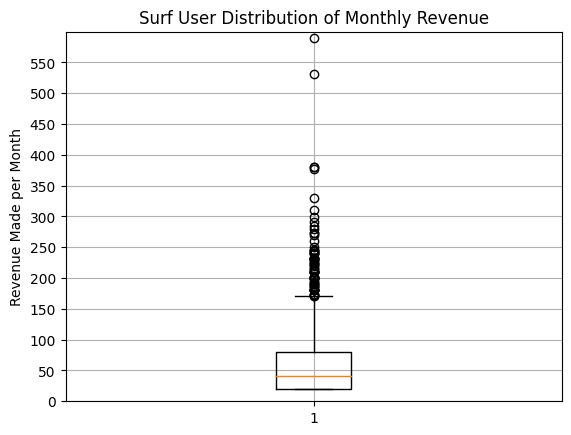

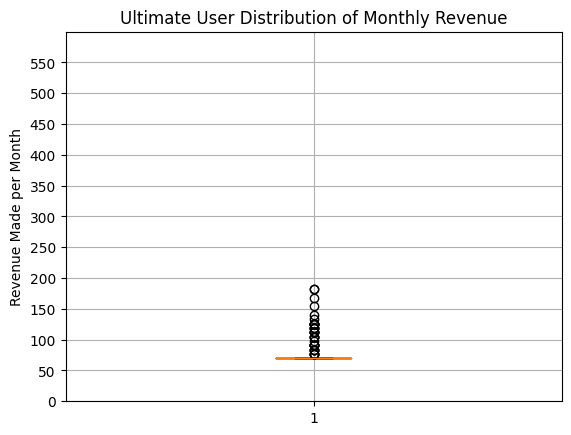

In [ ]:
# Plot a boxplot to visualize the distribution of the monthly call duration for each type of user

plt.boxplot(surf_users['monthly_revenue'])
plt.ylabel('Revenue Made per Month') 
plt.title('Surf User Distribution of Monthly Revenue')
plt.grid(True)
plt.yticks(range(0, 600, 50))
plt.ylim(0, 600)
plt.show()

plt.boxplot(ultimate_users['monthly_revenue'])
plt.ylabel('Revenue Made per Month') 
plt.title('Ultimate User Distribution of Monthly Revenue')
plt.grid(True)
plt.yticks(range(0, 600, 50))
plt.ylim(0, 600)
plt.show()

**Analysis:**
- The median for Ultimate users is just below 75. For Surf users, it's just below 50.
- The box is completely collapsed for Ultimate users because of how condensed the data is.
- Simultaniously, revenue from Surf users is much more varied and contains many more outliers, showing that customers frequently exceed their plans included minutes, messages, and megabytes.
- The stark contrast between these boxplots further demonstrates that Ultimate users don't put much of a strain on the network. Their usage rarely exceeds what's included in their plans.

## Test statistical hypotheses

**Formulated Hypotheses:**
- Null hypothesis: The average revenue from Ultimate users is the same as the average revenue from Surf users.
- Alternative hypothesis: The average revenue from Ultimate users is different from the average revenue from Surf users.

**Tested Hypothesis:**
- Because we are comparing the means of two independent groups (Surf versus Ultimate users), I chose an independent samples t-test.
- I decided on an alpha value of 5% because this provides an appropriate and standard 95% level of confidence for decision-making in business.

In [ ]:
# Create the t-test

alpha = 0.05

results = st.ttest_ind(surf_users['monthly_revenue'], ultimate_users['monthly_revenue'])

print('p-value: ', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis. The average revenue from Ultimate users is different from the average revenue from Surf users.")
else:
    print("We can't reject the null hypothesis. The average revenue from Ultimate users is the same as the average revenue from Surf users.")

p-value:  2.862674510698644e-08
We reject the null hypothesis. The average revenue from Ultimate users is different from the average revenue from Surf users.


**Formulated hypotheses:**
- Null hypothesis: The average revenue earned from customers in the NY-NJ area is equal to customers in other regions.
- Alternative hypothesis: The average revenue earned from customers in the NY-NJ area is different from that of the customers in the other regions.

**Tested Hypothesis:**
- Because we are comparing the means of two independent groups (NY-NJ users versus users in other regions), I chose an independent samples t-test.
- I decided on an alpha value of 5% because this provides an appropriate and standard 95% level of confidence for decision-making in business.

In [ ]:
# Separate users by geographic location

ny_nj_users = monthly_usage[monthly_usage['is_ny_nj'] == True]
other_users = monthly_usage[monthly_usage['is_ny_nj'] == False]

# Create the t-test

alpha = 0.05

results = st.ttest_ind(ny_nj_users['monthly_revenue'], other_users['monthly_revenue'])

print('p-value: ', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis. The average revenue earned from customers in the NY-NJ area is different from that of the customers in the other regions.")
else:
    print("We can't reject the null hypothesis. The average revenue earned from customers in the NY-NJ area is equal to customers in other regions.")



p-value:  0.043557431621342436
We reject the null hypothesis. The average revenue earned from customers in the NY-NJ area is different from that of the customers in the other regions.


## General conclusion

**Conclusion:**
- Overall, the Ultimate plan brings in more consistent revenue per user, while Surf revenue is much more varied from customer to customer.
- Ultimate users rarely exceed what is included in their plan. That keeps revenue steady and predictable, with most users staying close to the monthly plan price.
- Surf users exceed their included limits much more often, especially with megabytes and, in some cases, minutes. That creates more outliers and more variation in monthly revenue.
- Across calls, messages, and megabytes, usage generally increases as the year goes on and tends to peak in December. January is consistently the lowest point.
- In terms of call behavior, there is not a major difference between the two plans. Even though Ultimate includes more minutes, that does not seem to dramatically change how long customers talk on the phone each month.
- Message behavior shows more of a plan effect. Surf users appear to stay more aware of their message limit, while Ultimate users have so much included that they do not come close to using it all.
- Data usage is where the clearest difference appears. Surf users become much more likely to exceed their included megabytes during the second half of the year, while Ultimate users remain much more stable and usually stay within their plan limits.
- This suggests that many Surf customers are good candidates for upselling. The heavier users, especially those with large data overages, could benefit from upgrading, and Megaline could benefit from more stable revenue.
- The revenue analysis supports the idea that Ultimate users are more valuable on a monthly basis because their revenue is higher and much more consistent.
- At the same time, Surf remains an effective entry-level plan. It likely appeals to customers who want a lower base cost, even if that means occasional extra charges.

**Final interpretation:**
- Surf works well as a lower-cost plan, but it produces less predictable revenue and more heavy-use outliers.
- Ultimate works better as a higher-value plan because it brings in steadier revenue and serves customers whose usage patterns are more consistent.
- Based on this analysis, Megaline should consider putting more advertising focus on the Ultimate plan, while also targeting heavy Surf users for upgrade opportunities.
- The usage patterns also suggest there may be an opportunity to adjust the plan structure. This could include a mid-tier plan between Surf and Ultimate or a higher-tier option with unlimited minutes, messages, and megabytes included. The Ultimate plan data suggests that higher allowances do not necessarily lead to equal increases in usage across the user distribution.